Nama  : Michelle Sianturi
NIM   : 42324062
Prodi : D3 Teknologi Informasi

Praktikum Certan Week 5

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


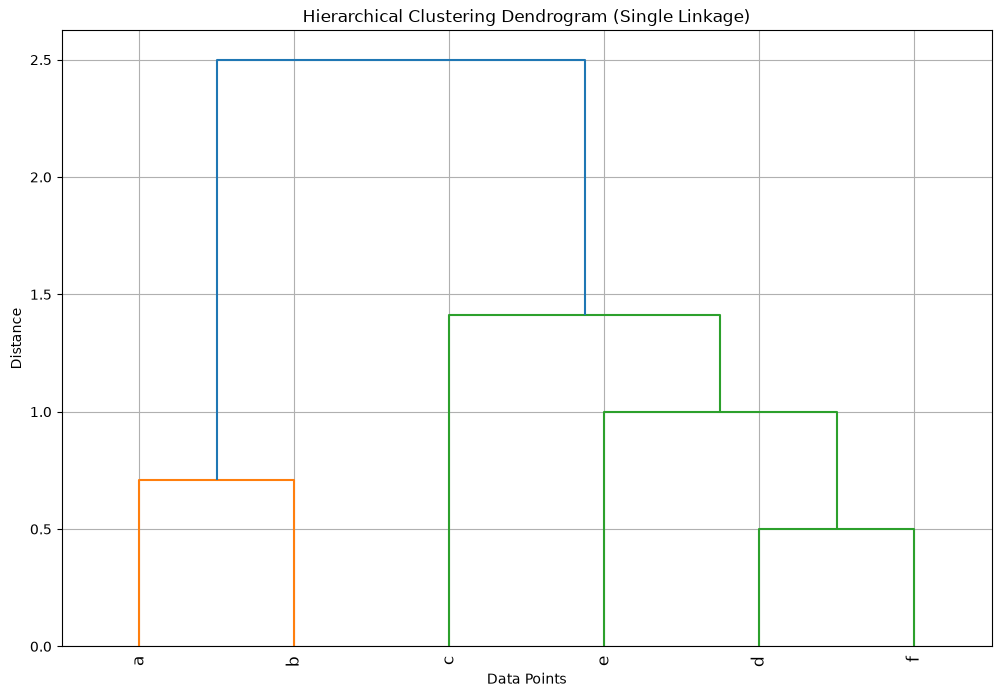

In [1]:

import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [3]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
x = df.iloc[:, [3, 4]].values

In [5]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

In [6]:

from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

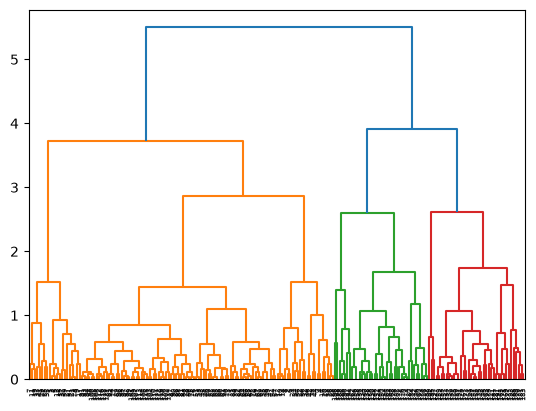

In [7]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

Tugas Certan Week 5

In [8]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])
labels = ['a', 'b', 'c', 'd', 'e', 'f']

Baris import memanggil alat yang dibutuhkan: numpy untuk membuat data berbentuk angka, linkage dan dendrogram dari scipy untuk melakukan clustering dan menggambar pohonnya, serta matplotlib untuk menampilkan gambar. Setelah itu dibuat variabel data yang berisi 6 titik dengan dua koordinat (x dan y), yaitu titik a sampai f. Variabel labels berisi nama-nama titik itu supaya di dendrogram yang tampil adalah huruf a-f, bukan nomor urut 0-5

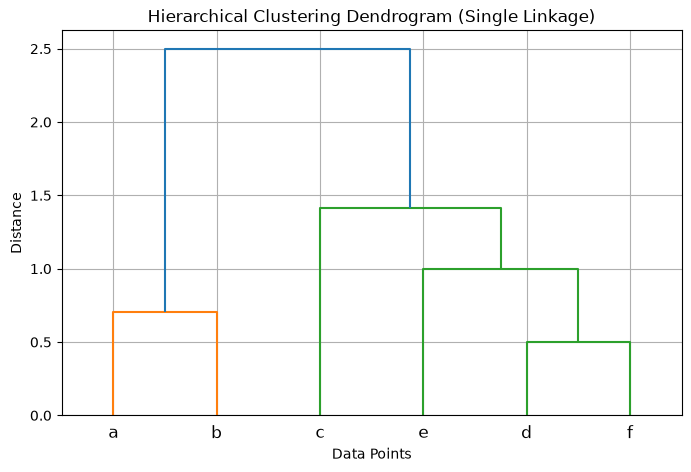

In [9]:
linked_single = linkage(data, method='single')
plt.figure(figsize=(8, 5))
dendrogram(linked_single, labels=labels)
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Baris linkage(data, method='single') adalah inti dari proses clustering. Fungsi ini menghitung jarak antar titik, lalu menggabungkan titik atau kelompok yang paling dekat secara bertahap sampai semuanya menjadi satu kelompok. Metode single berarti jarak antar dua kelompok diukur dari anggota mereka yang paling dekat. Hasilnya disimpan di linked_single, berupa tabel angka yang mencatat siapa digabung dengan siapa dan pada jarak berapa. Baris berikutnya menggambar tabel itu menjadi dendrogram: plt.figure(figsize=(8, 5)) mengatur ukuran gambar, dendrogram(...) menggambar pohonnya, lalu title, xlabel, dan ylabel memberi judul serta nama sumbu. plt.grid(True) menambah garis bantu agar tinggi penggabungan lebih mudah dibaca, dan plt.show() menampilkan hasilnya.

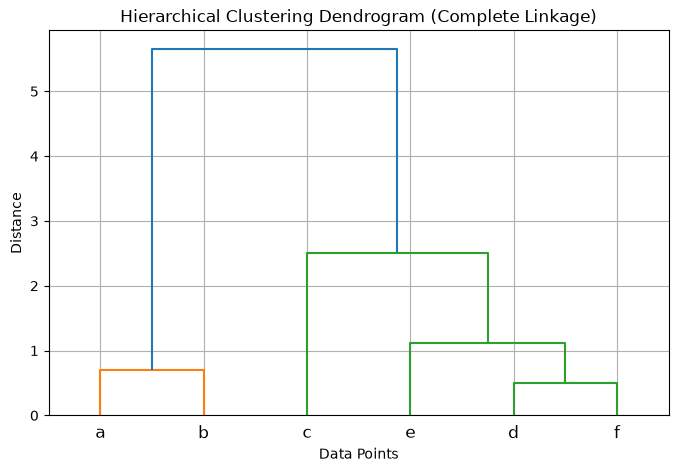

In [10]:
linked_complete = linkage(data, method='complete')
plt.figure(figsize=(8, 5))
dendrogram(linked_complete, labels=labels)
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Struktur kodenya sama persis dengan cell 2, hanya satu hal yang berbeda, yaitu method='complete'. Pada metode ini, jarak antar dua kelompok diukur dari anggota mereka yang paling jauh. Akibatnya, penggabungan baru terjadi ketika seluruh anggota kedua kelompok sudah cukup berdekatan, sehingga angka jarak pada dendrogram umumnya lebih besar dibanding single linkage dan kelompok yang terbentuk lebih padat. Hasilnya disimpan di linked_complete, dan judul gambarnya diganti agar kamu tidak tertukar saat membuat laporan.

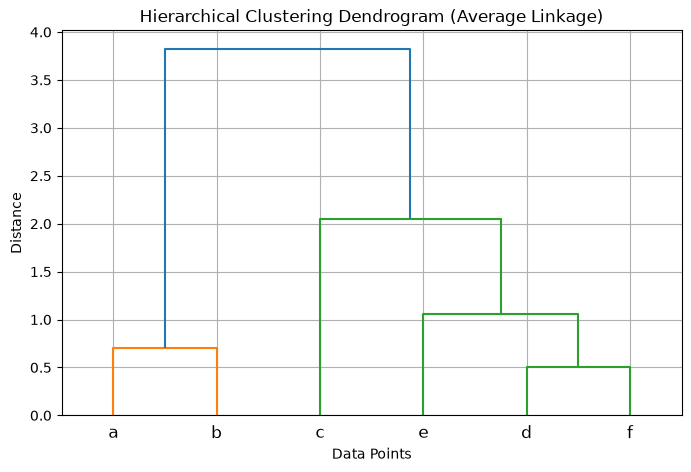

In [11]:
linked_average = linkage(data, method='average')
plt.figure(figsize=(8, 5))
dendrogram(linked_average, labels=labels)
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Lagi-lagi strukturnya sama, dengan perbedaan di method='average'. Metode ini menghitung rata-rata dari semua jarak antara anggota kelompok pertama dan anggota kelompok kedua. Karena itu hasilnya berada di tengah-tengah: tidak serendah single linkage dan tidak setinggi complete linkage. Hasilnya disimpan di linked_average.